# 05 · Lakebase — Managed Postgres for App State

**Pre-Hackathon Enablement · Notebook 5 of 6**

Genie answers questions about your *analytical* Delta tables. But an application
also needs **transactional state**: review queues, approvals, drafts, and — for
our app — a **conversation log**. That's what **Lakebase** (fully-managed
Postgres) is for.

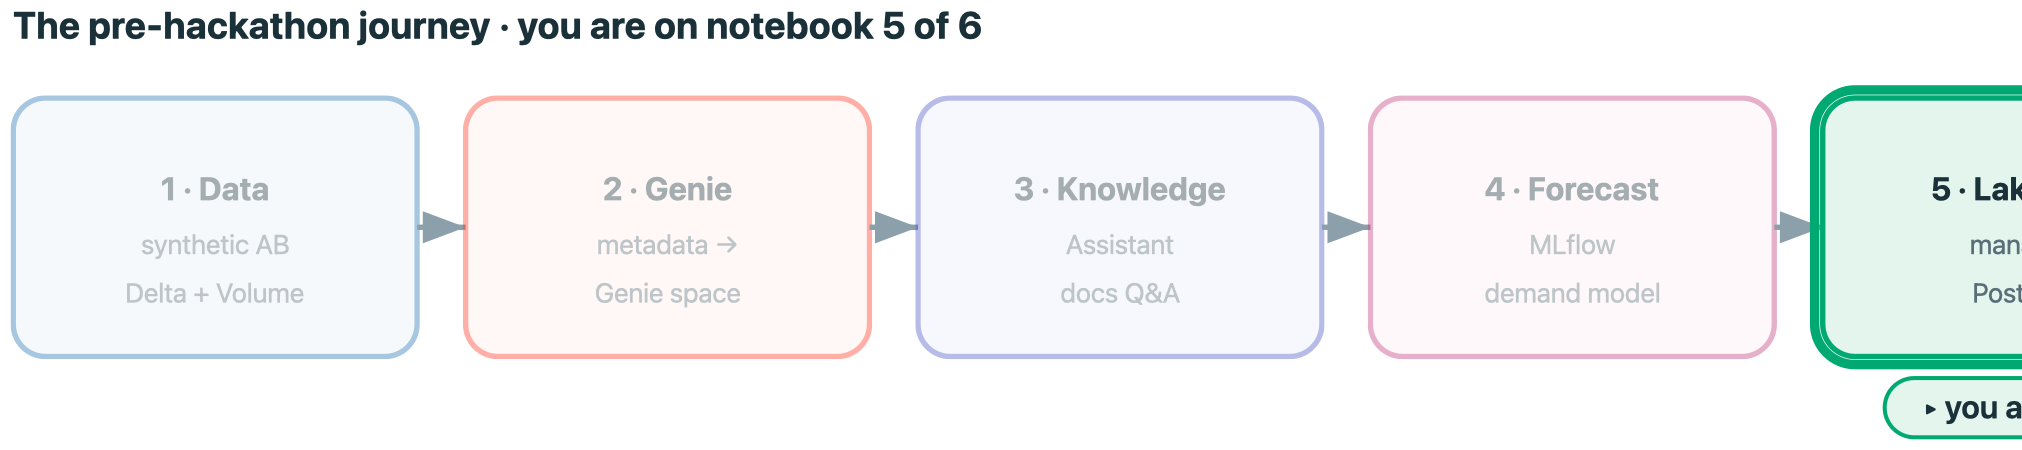

### When Lakebase, when Delta? (from the deck)
Reach for Lakebase for **operational, transactional** state — and keep analytics
in Delta. The app in Notebook 6 uses both: Genie reads Delta, the app writes its
conversation log to Lakebase.

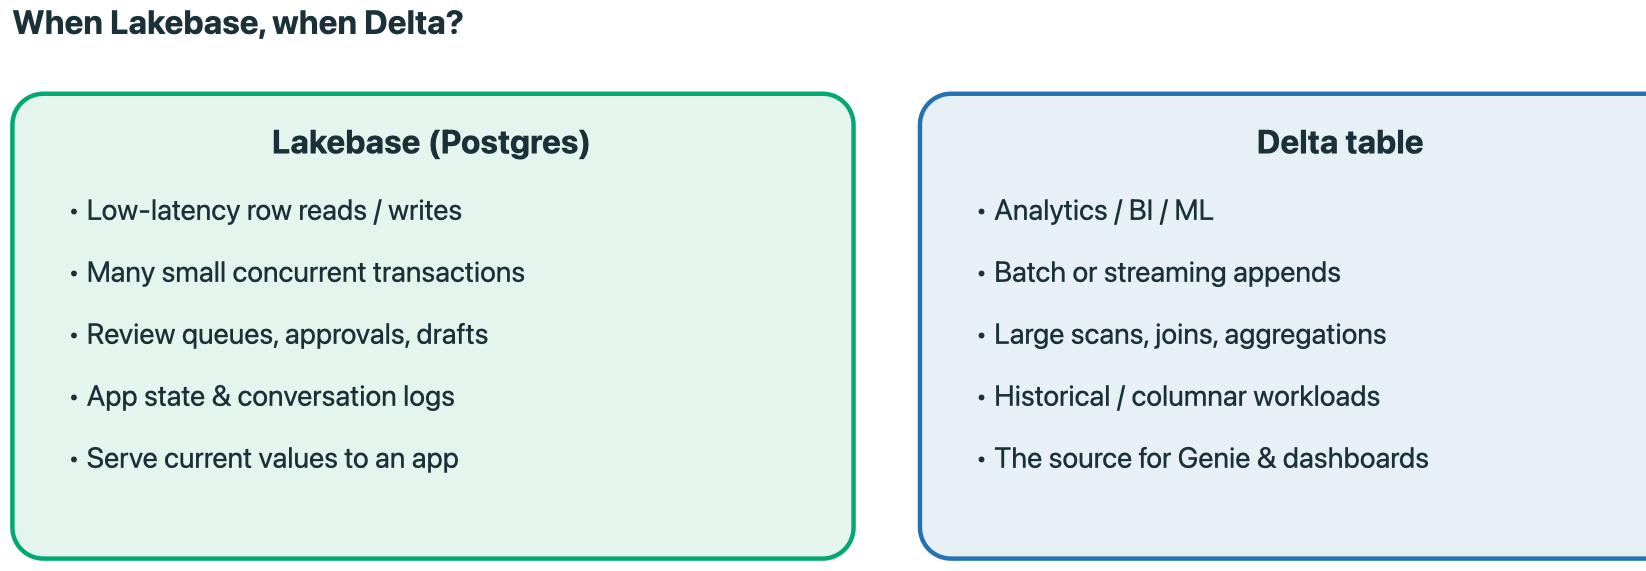

### The tables in our `app` schema

The `app` schema holds two kinds of table, grouped by **who fills them**:

- **Copied from Delta** — reference data and model output the app only *reads*
  (`products`, `distributors`, `demand_forecast`). We snapshot them from the Delta
  tables into Postgres with a simple `to_sql` copy.
- **Written by the app at runtime** — the transactional state Lakebase exists for:
  `conversations` (every Genie turn), `action_items` (a review queue), and
  `forecast_scenarios` (what-if predictions). The app `INSERT`/`UPDATE`/`DELETE`s these.

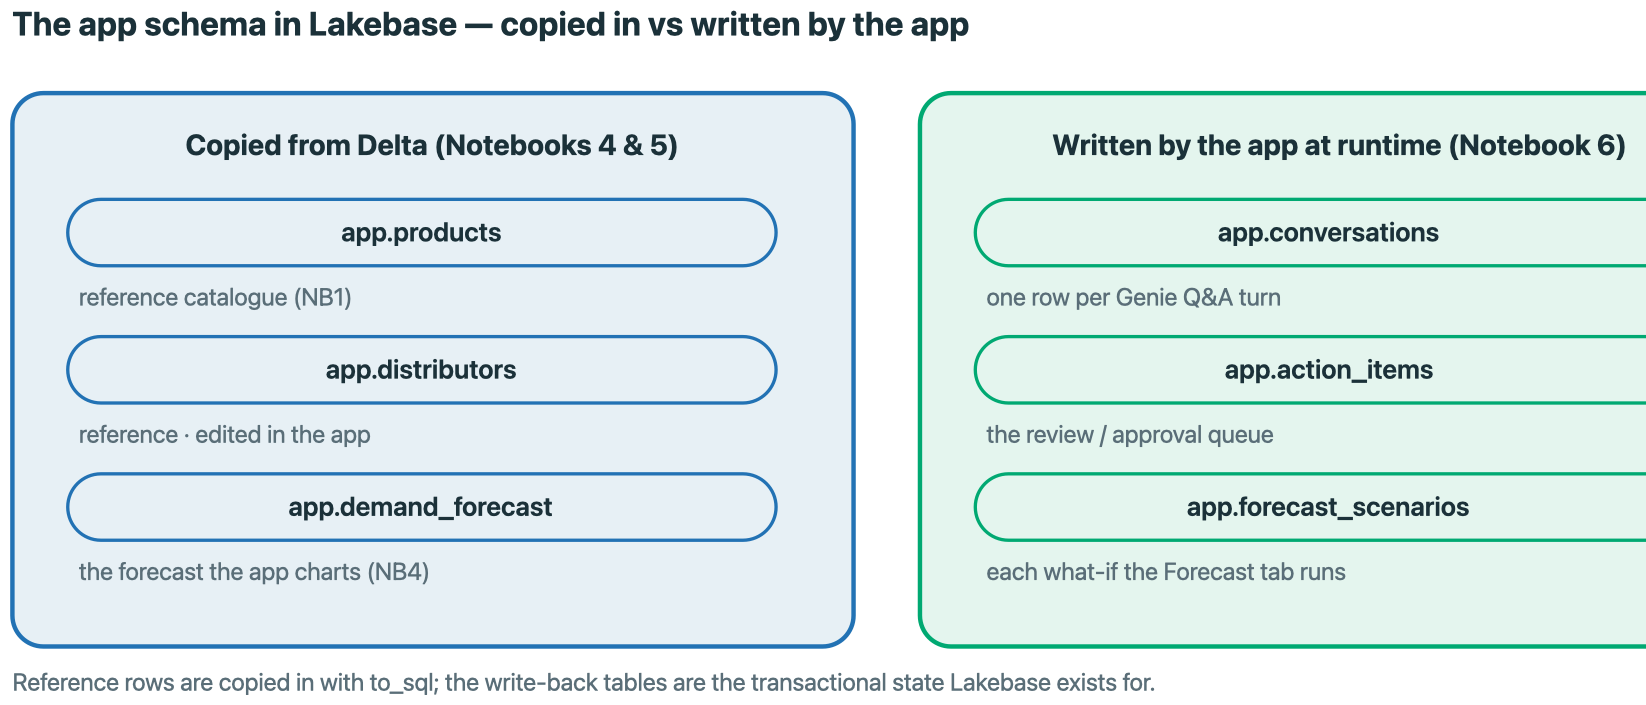

`distributors` is copied in but also **edited in the app** (the *Edit distributors*
tab), which is exactly the kind of low-latency read/write Lakebase is built for.

### What you'll do
1. Create a **Lakebase instance** (provisioned tier)
2. Create a logical database + `app` schema
3. Create the tables — the app's **write-back** tables plus the reference tables
4. **Copy** reference data (`products`, `distributors`) and the **`demand_forecast`**
   table (Notebook 4) from Delta → Lakebase with `to_sql`

> **Prerequisites:** an **FE-VM serverless workspace** (Lakebase needs serverless).
> Notebook 1 completed (`products`, `distributors`); Notebook 4 completed if you want
> the **`demand_forecast`** copied so the app can chart it. This notebook uses the
> Databricks SDK, so it runs from inside the workspace with no CLI needed.

In [ ]:
%pip install --quiet --upgrade databricks-sdk psycopg2-binary sqlalchemy
dbutils.library.restartPython()

In [ ]:
# Create the widgets. Run this cell, set the values up top, then run the next cell.
dbutils.widgets.text("catalog", "technology_dev", "Unity Catalog catalog")
dbutils.widgets.text("schema", "abi_hackathon", "Delta schema base (username appended — matches NB1)")
dbutils.widgets.text("lakebase_instance", "abi-hackathon-lakebase", "Lakebase instance name")
dbutils.widgets.text("app_db", "abi_app", "Lakebase logical DB base (username appended)")
dbutils.widgets.dropdown("capacity", "CU_2", ["CU_1", "CU_2", "CU_4", "CU_8"], "Instance capacity (shared instance — CU_2+ for a cohort)")

In [ ]:
# Now read the widgets and derive the per-user names.
# Per-user identity (deterministic). The Lakebase *instance* is shared (one is
# plenty and it's the pricey bit), but each user gets their own **logical DB**
# (abi_app_<user>) and their own Delta **schema** (matches Notebook 1) — so
# participants in a shared workspace never collide.
import re
CATALOG = dbutils.widgets.get("catalog").strip()
_user = spark.sql("SELECT current_user()").collect()[0][0]
_slug = re.sub(r"[^a-z0-9]+", "_", _user.split("@")[0].lower()).strip("_")[:30]
SCHEMA = f"{dbutils.widgets.get('schema').strip()}_{_slug}"
FQ = f"{CATALOG}.{SCHEMA}"
INSTANCE = dbutils.widgets.get("lakebase_instance").strip()   # shared instance
APP_DB = f"{dbutils.widgets.get('app_db').strip()}_{_slug}"    # per-user logical DB
CAPACITY = dbutils.widgets.get("capacity")
print(f"Delta source : {FQ}")
print(f"Lakebase     : instance='{INSTANCE}' db='{APP_DB}' capacity={CAPACITY}")

## Step 1 · Create (or reuse) the Lakebase instance

The Lakebase **instance is shared** across everyone — the widget name isn't
per-user. Each participant gets their own **logical database** (`abi_app_<you>`,
Step 3) *inside* this one instance; the instance is the provisioned/billed unit, so
one is plenty. This cell fetches it first and only creates it if missing, reusing it
otherwise (and starting it if it was auto-suspended).

> **Facilitators:** to avoid a cold-start race (many people creating the same
> instance at once) and N×5-min waits, **pre-create `abi-hackathon-lakebase` once**
> before the session — then everyone just reuses it. This cell is also
> concurrency-safe: if two people create it at the same time, the loser reuses it
> rather than erroring. For a large cohort, bump `capacity` (CU_2 / CU_4).

In [ ]:
import time
from databricks.sdk import WorkspaceClient
from databricks.sdk.service.database import DatabaseInstance

w = WorkspaceClient()

def get_instance(name):
    try:
        return w.database.get_database_instance(name=name)
    except Exception:
        return None

inst = get_instance(INSTANCE)
if inst is None:
    print(f"Creating shared Lakebase instance '{INSTANCE}' ({CAPACITY})…")
    try:
        w.database.create_database_instance(
            DatabaseInstance(name=INSTANCE, capacity=CAPACITY)
        )
    except Exception as e:  # noqa: BLE001
        # Concurrency-safe: in a workshop several people may hit "create" at the same
        # moment. If someone else just created it, reuse theirs instead of failing.
        inst = get_instance(INSTANCE)
        if inst is None:
            raise
        print(f"  Instance was created concurrently — reusing it. ({type(e).__name__})")
else:
    print(f"Instance '{INSTANCE}' already exists (state={inst.state}).")
    # A reused instance is often STOPPED (auto-suspended to save cost). Start it —
    # otherwise the wait-for-AVAILABLE loop below just spins until it times out.
    if getattr(inst, "stopped", False) or "STOPPED" in str(inst.state):
        print("  Instance is stopped — starting it (takes a few minutes)…")
        w.database.update_database_instance(
            name=INSTANCE,
            database_instance=DatabaseInstance(name=INSTANCE, stopped=False),
            update_mask="stopped",
        )

In [ ]:
# Wait for the instance to become AVAILABLE.
for _ in range(40):  # ~20 min max
    inst = get_instance(INSTANCE)
    state = str(inst.state) if inst else "UNKNOWN"
    print(f"  state = {state}")
    if "AVAILABLE" in state:
        break
    time.sleep(30)

assert inst and "AVAILABLE" in str(inst.state), "Instance not available yet — re-run this cell."
HOST = inst.read_write_dns
print(f"\nReady. read_write_dns = {HOST}")

## Step 2 · Connect with SQLAlchemy

Lakebase uses **OAuth tokens as the Postgres password** (they expire ~1 hour, so
we mint a fresh one when building the engine). Our Databricks identity is the
Postgres user.

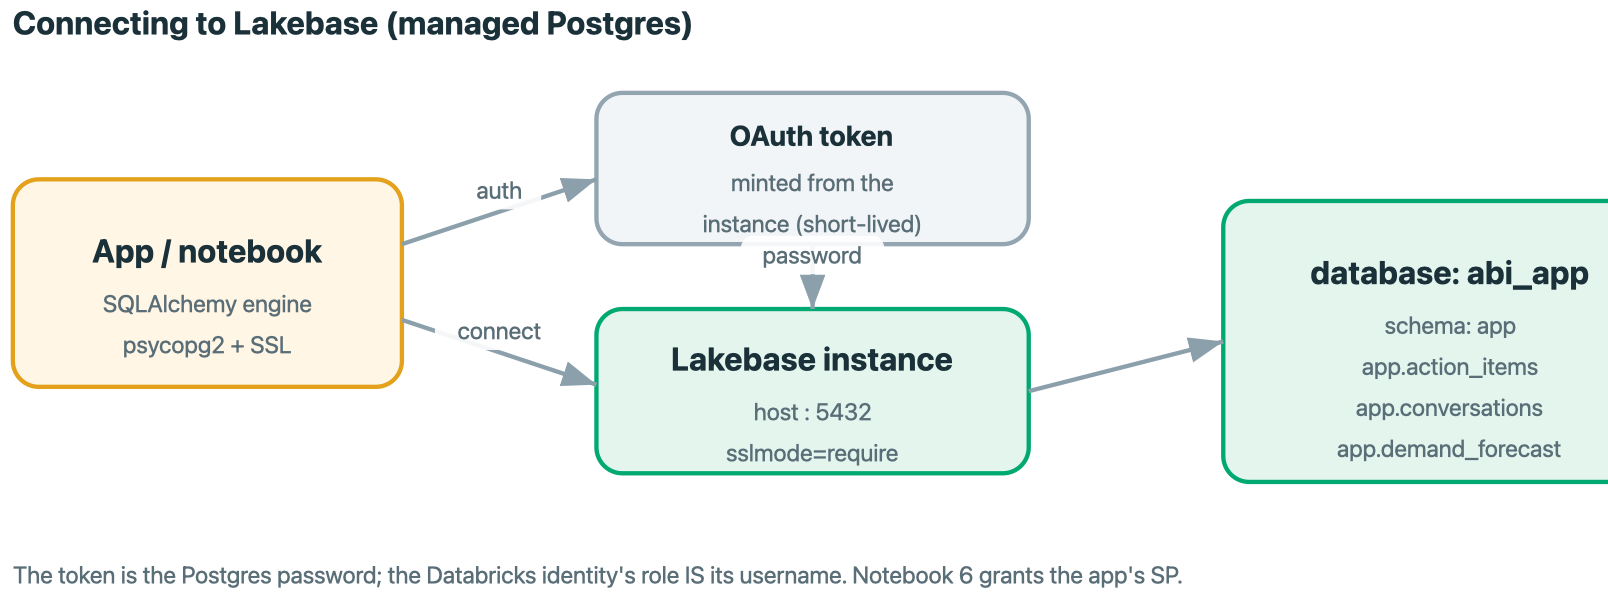

This is exactly how the **app** (Notebook 6) connects, too — same engine, same
short-lived token — except it authenticates as the app's **service principal**
rather than your user. The tables on the right are what we create in Steps 3–5.

In [ ]:
import uuid
from urllib.parse import quote_plus
from sqlalchemy import create_engine, text

PGUSER = w.current_user.me().user_name  # your Databricks email = Postgres role

def db_token():
    cred = w.database.generate_database_credential(
        request_id=str(uuid.uuid4()), instance_names=[INSTANCE]
    )
    return cred.token

def make_engine(dbname):
    token = db_token()
    url = (f"postgresql+psycopg2://{quote_plus(PGUSER)}:{quote_plus(token)}"
           f"@{HOST}:5432/{dbname}?sslmode=require")
    # isolation_level AUTOCOMMIT lets us run CREATE DATABASE (can't run in a txn).
    return create_engine(url, isolation_level="AUTOCOMMIT", pool_pre_ping=True)

# The default logical database that always exists on a Lakebase instance.
admin_engine = make_engine("databricks_postgres")
with admin_engine.connect() as c:
    print(c.execute(text("SELECT version();")).scalar())

## Step 3 · Create the logical database + `app` schema

A per-user logical database and an `app` schema to hold the tables.

In [ ]:
with admin_engine.connect() as c:
    exists = c.execute(
        text("SELECT 1 FROM pg_database WHERE datname = :n"), {"n": APP_DB}
    ).first()
    if not exists:
        c.execute(text(f'CREATE DATABASE "{APP_DB}"'))
        print(f"Created database '{APP_DB}'.")
    else:
        print(f"Database '{APP_DB}' already exists.")

# Connect to the app database and create the schema.
app_engine = make_engine(APP_DB)
with app_engine.begin() as c:
    c.execute(text("CREATE SCHEMA IF NOT EXISTS app"))
print("Schema 'app' ready.")

## Step 4 · Create the tables

Two reference tables (`app.products`, `app.distributors`) the app reads for fast
lookups **and edits back** (the "Edit distributors" tab), plus three **write-back**
tables: **`app.conversations`** (every Genie Q&A turn), **`app.action_items`** (a
review/approval queue), and **`app.forecast_scenarios`** (what-if predictions from
the Forecast tab). This transactional read/write state is the whole point of Lakebase.

In [ ]:
DDL = """
CREATE TABLE IF NOT EXISTS app.products (
    product_sku     TEXT PRIMARY KEY,
    product_name    TEXT NOT NULL,
    brand           TEXT,
    category        TEXT,
    package_type    TEXT,
    units_per_case  INT,
    unit_cost_usd   NUMERIC(10,2),
    list_price_usd  NUMERIC(10,2)
);

CREATE TABLE IF NOT EXISTS app.distributors (
    distributor_id    TEXT PRIMARY KEY,
    distributor_name  TEXT NOT NULL,
    region            TEXT,
    state             TEXT,
    city              TEXT,
    tier              TEXT,
    credit_limit_usd  NUMERIC(12,2),
    onboarded_date    DATE
);

CREATE TABLE IF NOT EXISTS app.conversations (
    id                SERIAL PRIMARY KEY,
    session_id        TEXT NOT NULL,
    user_email        TEXT,
    question          TEXT NOT NULL,
    answer_text       TEXT,
    generated_sql     TEXT,
    result_row_count  INT,
    conversation_id   TEXT,
    message_id        TEXT,
    created_at        TIMESTAMP DEFAULT NOW()
);

-- Transactional app state written by the app's "Action items" tab (Notebook 6):
-- a review/approval queue — the kind of read/write workload Lakebase exists for.
CREATE TABLE IF NOT EXISTS app.action_items (
    id          SERIAL PRIMARY KEY,
    created_by  TEXT,
    title       TEXT NOT NULL,
    note        TEXT,
    status      TEXT DEFAULT 'Open',
    created_at  TIMESTAMP DEFAULT NOW()
);

-- What-if scenarios written by the app's Forecast tab (Notebook 6): each live
-- inference call against the demand-forecast serving endpoint is saved here.
CREATE TABLE IF NOT EXISTS app.forecast_scenarios (
    id               BIGSERIAL PRIMARY KEY,
    created_by       TEXT,
    segment          TEXT,
    lag_1            DOUBLE PRECISION,
    lag_2            DOUBLE PRECISION,
    lag_3            DOUBLE PRECISION,
    target_month     INT,
    trend            INT,
    predicted_cases  DOUBLE PRECISION,
    created_at       TIMESTAMP DEFAULT NOW()
);

CREATE INDEX IF NOT EXISTS idx_conversations_session ON app.conversations(session_id);
CREATE INDEX IF NOT EXISTS idx_conversations_created ON app.conversations(created_at);
"""
with app_engine.begin() as c:
    for stmt in [s for s in DDL.split(";") if s.strip()]:
        c.execute(text(stmt))
print("Tables created: app.products, app.distributors, app.conversations, "
      "app.action_items, app.forecast_scenarios")

## Step 5 · Copy reference data + the forecast from Delta → Lakebase

Read the Delta tables into pandas and bulk-load them into Lakebase. For the modest
reference tables here, pandas `to_sql` is perfectly fine. The **`demand_forecast`**
table (Notebook 4) is copied the same way so the Notebook 6 app can chart it from
Postgres. (`if_exists="replace"` = drop + reload, so re-running the notebook is safe.)

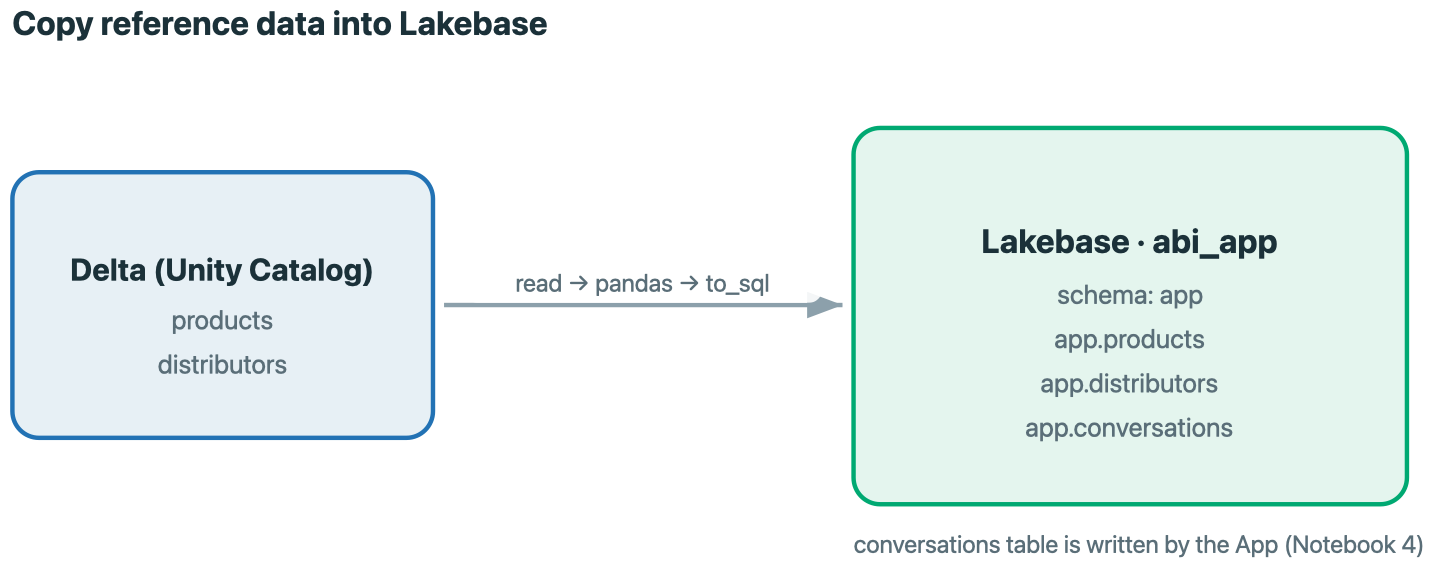

In [ ]:
import pandas as pd

def copy_table(delta_name, pg_table):
    pdf = spark.table(f"{FQ}.{delta_name}").toPandas()
    # replace = truncate + reload, so re-running the notebook is safe.
    pdf.to_sql(pg_table, app_engine, schema="app", if_exists="replace", index=False)
    print(f"  copied {delta_name} -> app.{pg_table}  ({len(pdf)} rows)")

print("Copying reference data…")
copy_table("products", "products")
copy_table("distributors", "distributors")

# The demand forecast from Notebook 4 (the app charts this). Skip gracefully if
# you haven't run Notebook 4 yet.
try:
    copy_table("demand_forecast", "demand_forecast")
except Exception as e:
    print(f"  (skipped demand_forecast — run Notebook 4 first: {e})")
print("Done.")

## Step 6 · Verify

In [ ]:
with app_engine.connect() as c:
    for t in ["products", "distributors", "conversations", "action_items",
              "forecast_scenarios", "demand_forecast"]:
        try:
            n = c.execute(text(f"SELECT COUNT(*) FROM app.{t}")).scalar()
            print(f"app.{t:18s} {n:>6} rows")
        except Exception:
            print(f"app.{t:18s}    (not present yet)")
    print("\nSample distributors:")
    for row in c.execute(text("SELECT distributor_name, region, tier FROM app.distributors LIMIT 5")):
        print("  ", row)

## Going further · Reverse ETL & permissions

Copying data from Delta into Lakebase — as Step 5 did — is a small example of
**reverse ETL**: moving *analytical* data from the lakehouse into an *operational*
store an app can serve with low latency. There's a spectrum of ways to do it:

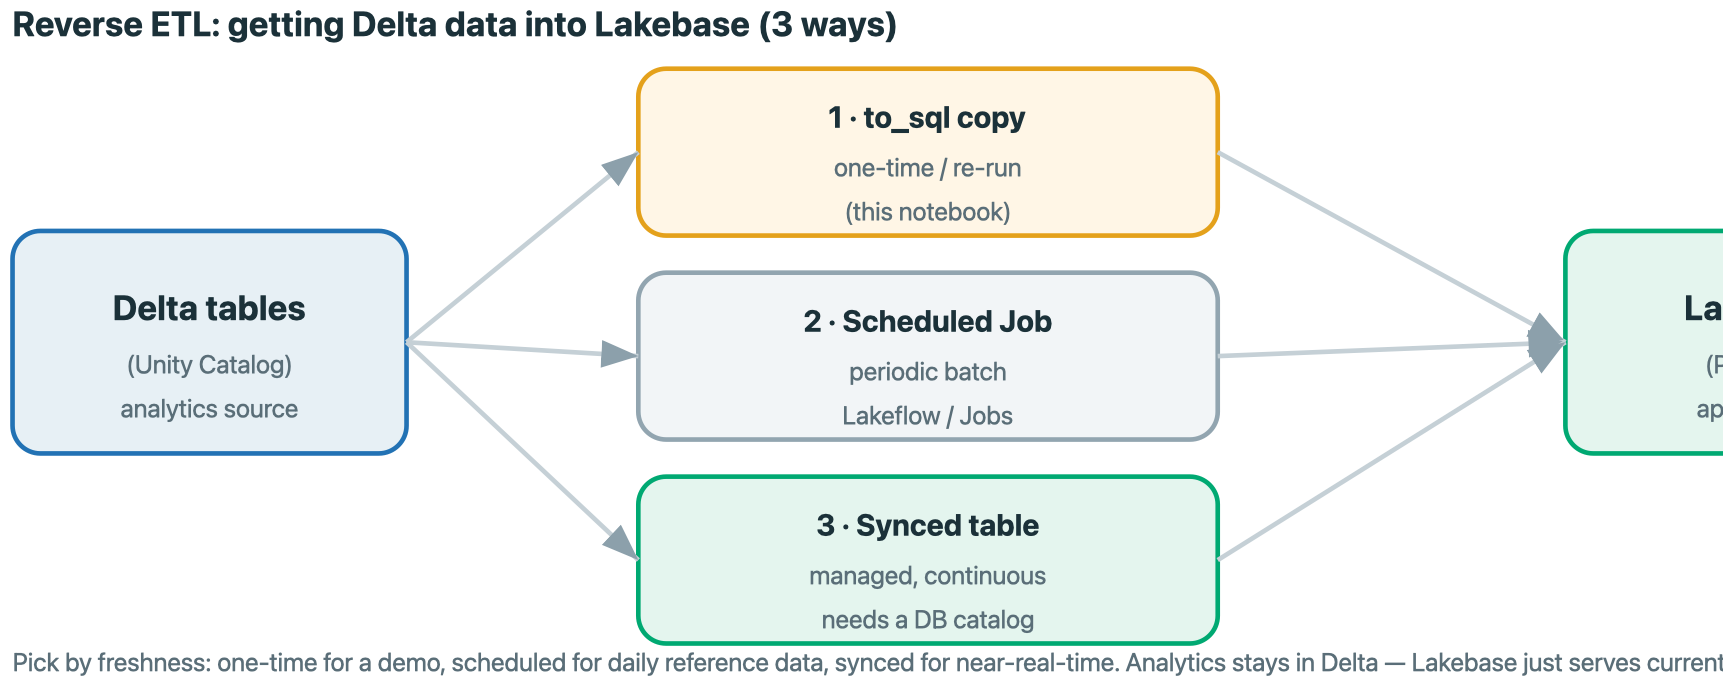

- **1 · `to_sql` copy** (what this notebook does) — a one-time / on-demand snapshot.
  Great for a demo or reference data that rarely changes; re-run to refresh.
- **2 · Scheduled Job** — wrap the copy in a Databricks **Job** (or a Lakeflow
  pipeline) on a schedule so Postgres refreshes nightly/hourly. Still your code.
- **3 · Synced table** — a **managed, UC-governed** Delta→Postgres mirror that keeps
  itself fresh (snapshot / triggered / continuous): no copy code, and it appears in
  Unity Catalog — but it's **read-only**, and registering it needs a *database
  catalog* (see permissions below).

Rule of thumb: **copy or sync what only Delta owns (read-only reference + model
output); keep native Postgres tables for anything the app writes.**

### Permissions & the steps each path needs

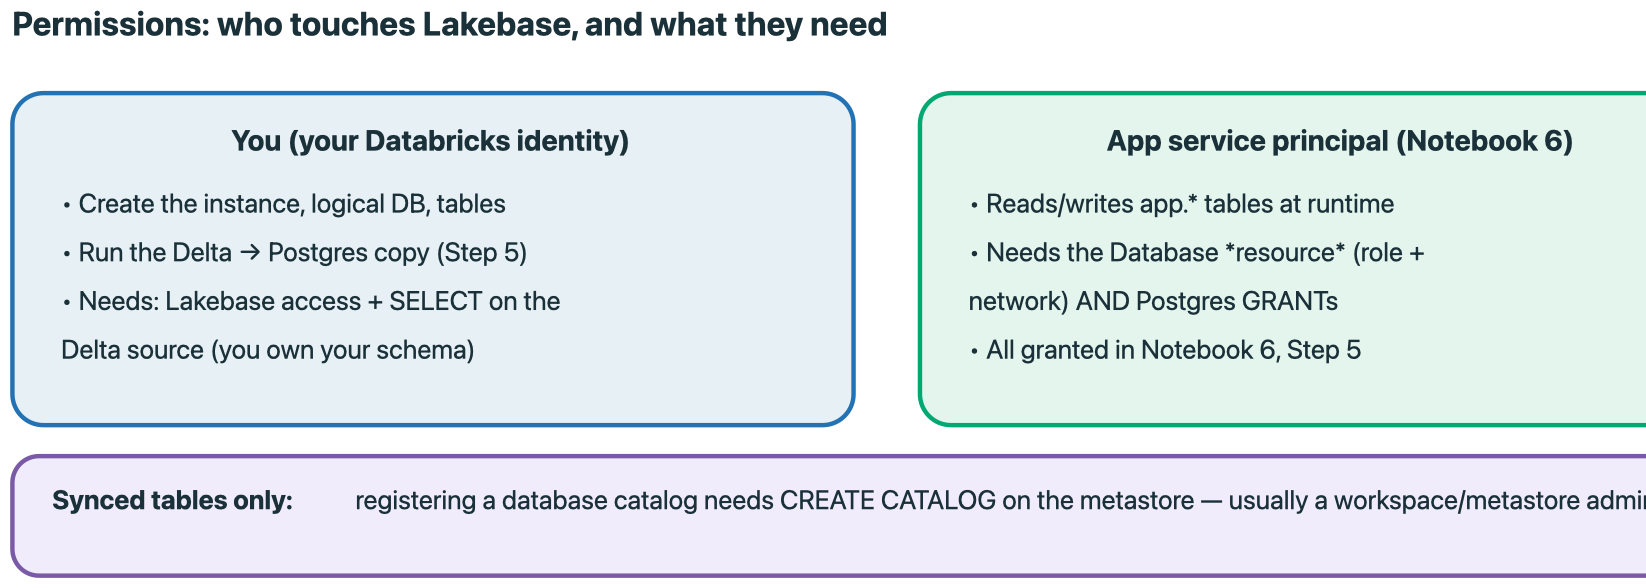

- **You (running these notebooks)** need Lakebase access + `SELECT` on your Delta
  source (you own your schema) — that covers Steps 1–6 here.
- **The app's service principal** (Notebook 6) needs the **Database resource**
  (Lakebase role + network) *and* Postgres `GRANT`s on the `app.*` tables — all done
  in **Notebook 6, Step 5**. Attaching the resource is what gives the SP its role.
- **Synced tables only:** registering a **database catalog** (so the synced table is
  a governed UC object) needs **`CREATE CATALOG` on the metastore** — usually a
  workspace/metastore admin, not each participant. The steps: **(1)** an admin
  registers the database catalog once, **(2)** create the synced table from the Delta
  source with a primary key + a scheduling policy (SNAPSHOT / TRIGGERED / CONTINUOUS),
  **(3)** grant the app SP `SELECT` on it. Without `CREATE CATALOG`, use the `to_sql`
  copy above.

## ✅ Recap & what's next

You provisioned a **Lakebase** instance, created the `abi_app` database with an
`app` schema, and loaded reference data (`products`, `distributors`), the
**`demand_forecast`**, and the write-back tables (`conversations`, `action_items`,
`forecast_scenarios`).

**Key ideas**
- Lakebase = **managed Postgres** for low-latency, transactional **app state**.
- OAuth token = the Postgres password (short-lived; mint fresh).
- Reference data + the forecast are **copied** with `to_sql`; for large or
  continuously-updated tables you'd reach for a Lakebase **synced table** (a
  UC-governed, managed Delta→Postgres mirror) instead — it needs a database catalog.
- Analytics stays in Delta/Genie; **operational writes** (the conversation log, the
  review queue) go to Lakebase.

You've now built every data + AI piece the app needs (Genie, Knowledge Assistant,
forecast, Lakebase). **Next → Notebook 6:** the **Databricks App** that wires Genie +
Knowledge Assistant + forecast + Lakebase into one UI. *(There's also an optional,
unnumbered **Genie Code** notebook — a governed AI-assisted-development playbook that
needs only Notebooks 1–2; do it any time.)*